<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_AR_AK_analyst_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Kalyani STUDY PATIENT.xlsx')

In [33]:
df.columns

Index(['IP NUMBER ', 'NAME ', 'AGE', 'SEX', 'DIAGNOSIS', 'KH', 'KV', 'AX',
       'AL', 'ACD', 'LT', 'V/A PRE OP', 'POD 1 DAY V/A', 'SPH', 'CYL', 'AXIS',
       'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ', 'CYL.1', 'AXIS.1',
       'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1', 'CYL ', 'AXIS.2',
       'POD 3  MONTH    AR'],
      dtype='object')

In [34]:
df.head()

,IP NUMBER,NAME,AGE,SEX,DIAGNOSIS,KH,KV,AX,AL,ACD,...,POD 6 WEEK V/A,SPH,CYL.1,AXIS.1,POD 6 WEEK AR,POD 3 MONTH V/A,SPH.1,CYL,AXIS.2,POD 3 MONTH AR
0,2682458,NAGAMMA,54,F,LE MC,46.50,47.25,155,22.65,2.76,...,6\12,0.25,-1.25,100.0,+0.25/-1.25/100,6\9,0.5,-1.0,65.0,+0.50/-1.00/65
1,2682462,GOWRAMMA,63,F,LE MC,46.75,48.00,80,21.90,1.99,...,6\18,0.75,-2.00,90.0,+0.75/-2.00/90,6\12,0.5,-2.0,80.0,+0.50/-2.00/80
2,2682451,SUNDRAMMA,78,F,RE BROWN CATARACT,44.00,44.25,20,22.91,3.08,...,6\24,-1.5,-1.00,140.0,-1.50/-1.00/140,NaN,NaN,NaN,NaN,NaN
3,2683506,KUNNABASAMMA,71,F,RE NS II + PSC,45.25,45.75,120,22.32,3.48,...,6\18,-0.5,-0.75,140.0,-0.5/-0.75/140,6\9,-0.5,-0.5,150.0,-0.5/-0.50/150
4,2689441,SANNAIAH,89,M,LE NS II + PSC + CC,45.50,47.00,80,22.31,3.06,...,6\12,0.25,2.25,85.0,+0.25/+2.25/85,NaN,NaN,NaN,NaN,NaN


In [35]:
df1 = df.drop(['IP NUMBER ','DIAGNOSIS','AL', 'ACD', 'LT'], axis=1)
df1.columns


Index(['NAME ', 'AGE', 'SEX', 'KH', 'KV', 'AX', 'V/A PRE OP', 'POD 1 DAY V/A',
       'SPH', 'CYL', 'AXIS', 'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ',
       'CYL.1', 'AXIS.1', 'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1',
       'CYL ', 'AXIS.2', 'POD 3  MONTH    AR'],
      dtype='object')

In [36]:
day1AR = df[['KH','KV', 'AX', 'SPH', 'CYL', 'AXIS']].dropna(axis=0)
day1AR

,KH,KV,AX,SPH,CYL,AXIS
0,46.50,47.25,155,0.25,-1.50,115.0
1,46.75,48.00,80,0.75,-2.25,80.0
3,45.25,45.75,120,-0.75,-1.00,160.0
4,45.50,47.00,80,0.25,2.00,75.0
5,42.50,43.50,75,2,-2.00,90.0
...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0
167,47.00,48.25,165,1.25,-1.75,15.0
168,42.00,42.50,110,-0.75,-1.25,95.0
169,45.00,46.25,165,-2.75,-3.00,75.0


In [37]:
day1AR.shape, day1AR.columns

((131, 6), Index(['KH', 'KV', 'AX', 'SPH', 'CYL', 'AXIS'], dtype='object'))

In [38]:
# Create a new column 'Classification' in day1ARclean
day1AR['Classification'] = day1AR.apply(
    lambda row: 'Myopic Astigmatism' if row['SPH'] < 0 and row['CYL'] < 0 else
                'Hyperopic Astigmatism' if row['SPH'] > 0 and row['CYL'] > 0 else
                'Mixed Astigmatism' if row['CYL'] > 0 else
                'Mixed Astigmatism',
    axis=1
)

# View result
print(day1AR[['SPH', 'CYL', 'Classification']])


      SPH   CYL         Classification
0    0.25 -1.50      Mixed Astigmatism
1    0.75 -2.25      Mixed Astigmatism
3   -0.75 -1.00     Myopic Astigmatism
4    0.25  2.00  Hyperopic Astigmatism
5       2 -2.00      Mixed Astigmatism
..    ...   ...                    ...
165 -2.75 -3.00     Myopic Astigmatism
167  1.25 -1.75      Mixed Astigmatism
168 -0.75 -1.25     Myopic Astigmatism
169 -2.75 -3.00     Myopic Astigmatism
173 -3.25 -3.00     Myopic Astigmatism

[131 rows x 3 columns]


In [39]:
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism
...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,Myopic Astigmatism
167,47.00,48.25,165,1.25,-1.75,15.0,Mixed Astigmatism
168,42.00,42.50,110,-0.75,-1.25,95.0,Myopic Astigmatism
169,45.00,46.25,165,-2.75,-3.00,75.0,Myopic Astigmatism


In [40]:
# Frequency of each refractive error type
classification_counts = day1AR['Classification'].value_counts()
print(classification_counts)


Classification
Mixed Astigmatism        69
Myopic Astigmatism       48
Hyperopic Astigmatism    14
Name: count, dtype: int64


In [41]:
# Descriptive stats by classification group
grouped_stats = day1AR.groupby('Classification')[['SPH', 'CYL', 'AXIS']].describe()
print(grouped_stats)


                        CYL                                                \
                      count      mean       std   min     25%   50%   75%   
Classification                                                              
Hyperopic Astigmatism  14.0  1.928571  1.178447  0.50  0.8125  1.75  3.00   
Mixed Astigmatism      69.0 -1.952899  1.711915 -5.75 -2.7500 -1.75 -1.25   
Myopic Astigmatism     48.0 -1.848958  1.248126 -4.75 -2.6250 -1.25 -1.00   

                             AXIS                                        \
                        max count    mean        std   min    25%   50%   
Classification                                                            
Hyperopic Astigmatism  3.75  14.0  97.000  42.197339  18.0  76.25  95.0   
Mixed Astigmatism      3.75  69.0  85.000  30.976746  10.0  75.00  85.0   
Myopic Astigmatism    -0.50  48.0  93.125  43.924803   5.0  65.00  95.0   

                                      
                          75%    max  
Classifi

In [42]:
pivot = day1AR.pivot_table(index='Classification',
                                 values=['SPH', 'CYL', 'AXIS'],
                                 aggfunc=['mean', 'std', 'min', 'max', 'count'])
print(pivot)


                         mean                            std            \
                         AXIS       CYL       SPH       AXIS       CYL   
Classification                                                           
Hyperopic Astigmatism  97.000  1.928571  1.214286  42.197339  1.178447   
Mixed Astigmatism      85.000 -1.952899  0.985507  30.976746  1.711915   
Myopic Astigmatism     93.125 -1.848958     -1.25  43.924803  1.248126   

                                  min                max             count  \
                            SPH  AXIS   CYL   SPH   AXIS   CYL   SPH  AXIS   
Classification                                                               
Hyperopic Astigmatism  0.908598  18.0  0.50  0.25  175.0  3.75   3.5    14   
Mixed Astigmatism      0.905340  10.0 -5.75 -2.25  175.0  3.75   3.0    69   
Myopic Astigmatism     0.862949   5.0 -4.75 -3.25  180.0 -0.50 -0.25    48   

                               
                      CYL SPH  
Classification        

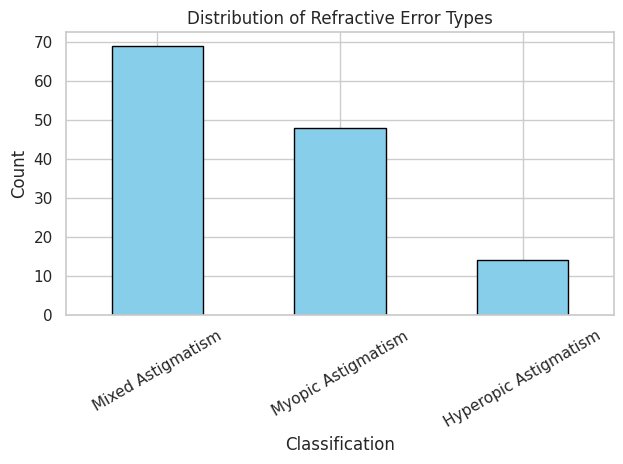

In [43]:
import matplotlib.pyplot as plt

day1AR['Classification'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Refractive Error Types')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


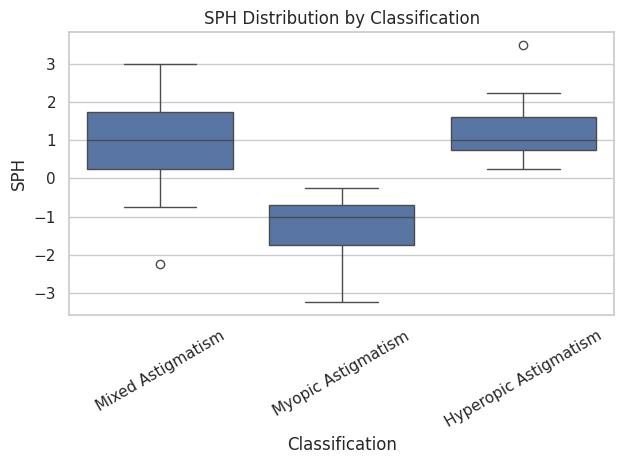

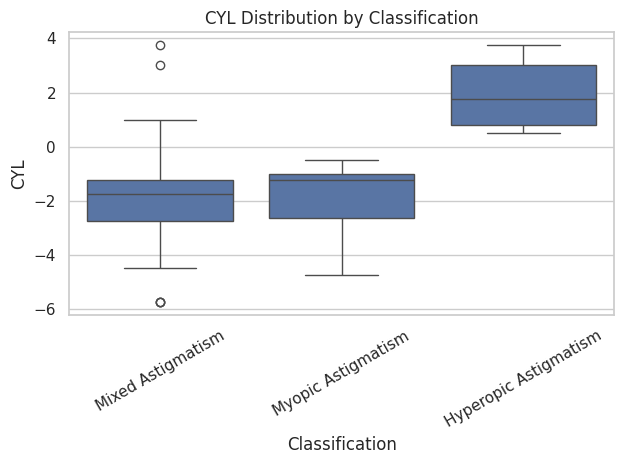

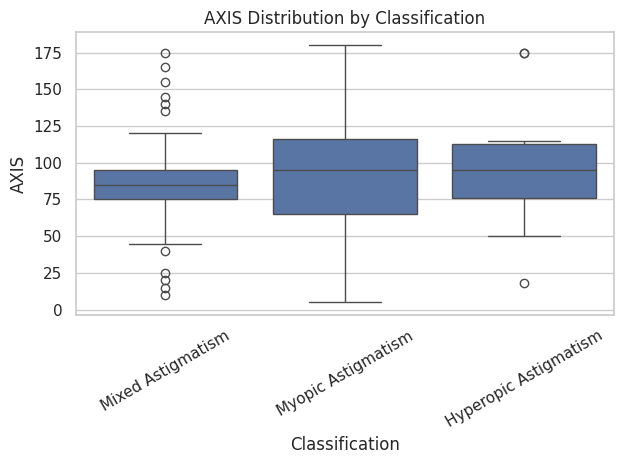

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# SPH boxplot
sns.boxplot(x='Classification', y='SPH', data=day1AR)
plt.title('SPH Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# CYL boxplot
sns.boxplot(x='Classification', y='CYL', data=day1AR)
plt.title('CYL Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# AXIS boxplot
sns.boxplot(x='Classification', y='AXIS', data=day1AR)
plt.title('AXIS Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [45]:
# Separate Myopic Astigmatism
myopic_df = day1AR[day1AR['Classification'] == 'Myopic Astigmatism']

# Separate Hyperopic Astigmatism
hyperopic_df = day1AR[day1AR['Classification'] == 'Hyperopic Astigmatism']

# Separate Mixed Astigmatism
mixed_df = day1AR[day1AR['Classification'] == 'Mixed Astigmatism']


In [46]:
myopic_df.shape, hyperopic_df.shape, mixed_df.shape

((48, 7), (14, 7), (69, 7))

In [47]:
myopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism
7,43.00,44.50,90,-1,-0.50,100.0,Myopic Astigmatism
12,43.00,43.75,65,-1,-1.00,95.0,Myopic Astigmatism
17,44.75,45.25,80,-1.75,-1.25,15.0,Myopic Astigmatism
32,41.00,41.75,145,-0.5,-1.00,100.0,Myopic Astigmatism
37,43.25,44.00,125,-1.75,-3.75,80.0,Myopic Astigmatism
41,40.25,41.25,75,-1,-0.75,70.0,Myopic Astigmatism
42,44.00,44.25,140,-1.5,-1.00,50.0,Myopic Astigmatism
50,44.00,44.50,155,-0.75,-0.50,30.0,Myopic Astigmatism
52,45.00,45.25,175,-0.75,-1.25,75.0,Myopic Astigmatism


In [48]:
hyperopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism
9,47.50,48.00,5,0.25,3.50,18.0,Hyperopic Astigmatism
19,43.75,45.00,85,2,3.00,105.0,Hyperopic Astigmatism
67,46.00,48.25,170,1,0.75,95.0,Hyperopic Astigmatism
76,44.50,44.75,55,1,0.50,95.0,Hyperopic Astigmatism
95,46.75,47.00,75,2.25,3.00,175.0,Hyperopic Astigmatism
110,44.00,45.50,90,1.75,2.25,100.0,Hyperopic Astigmatism
112,41.75,42.25,85,1.25,1.00,65.0,Hyperopic Astigmatism
113,45.25,46.00,90,1.25,0.75,115.0,Hyperopic Astigmatism
135,43.75,43.75,180,0.75,0.75,115.0,Hyperopic Astigmatism


In [49]:
mixed_df

,KH,KV,AX,SPH,CYL,AXIS,Classification
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism
6,43.50,44.00,20,-0.5,3.75,75.0,Mixed Astigmatism
8,44.75,45.25,85,1.5,-3.25,45.0,Mixed Astigmatism
...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,Mixed Astigmatism
155,44.25,45.75,80,1.25,-1.00,80.0,Mixed Astigmatism
159,41.75,43.50,160,-2.25,3.00,50.0,Mixed Astigmatism
163,45.25,45.25,180,1.75,-4.25,95.0,Mixed Astigmatism


In [50]:
myopic_df.describe()

,KH,KV,AX,CYL,AXIS
count,48.000000,48.000000,48.00000,48.000000,48.000000
mean,44.473958,45.312500,105.93750,-1.848958,93.125000
std,1.896413,1.911958,49.05117,1.248126,43.924803
min,40.000000,41.250000,10.00000,-4.750000,5.000000
25%,43.250000,44.000000,68.75000,-2.625000,65.000000
50%,44.750000,45.250000,102.50000,-1.250000,95.000000
75%,46.000000,47.000000,151.25000,-1.000000,116.250000
max,48.500000,49.500000,180.00000,-0.500000,180.000000


In [51]:
myopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS
KH,1.000000,0.947042,0.036293,-0.113761,-0.056731,0.112745
KV,0.947042,1.000000,-0.008578,-0.087045,-0.110474,0.084079
AX,0.036293,-0.008578,1.000000,0.202318,0.372538,-0.190991
SPH,-0.113761,-0.087045,0.202318,1.000000,0.514843,0.159273
CYL,-0.056731,-0.110474,0.372538,0.514843,1.000000,-0.033534
AXIS,0.112745,0.084079,-0.190991,0.159273,-0.033534,1.000000


In [52]:
hyperopic_df.describe()

,KH,KV,AX,CYL,AXIS
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,44.625000,45.517857,89.642857,1.928571,97.000000
std,1.818045,1.993895,44.352794,1.178447,42.197339
min,41.500000,42.250000,5.000000,0.500000,18.000000
25%,43.750000,44.000000,76.250000,0.812500,76.250000
50%,44.625000,45.750000,85.000000,1.750000,95.000000
75%,45.875000,47.000000,90.000000,3.000000,112.500000
max,47.500000,48.250000,180.000000,3.750000,175.000000


In [53]:
hyperopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS
KH,1.000000,0.935679,-0.125804,0.253209,0.177276,0.212320
KV,0.935679,1.000000,-0.080381,0.194104,0.133580,0.085255
AX,-0.125804,-0.080381,1.000000,0.219173,-0.361098,0.475948
SPH,0.253209,0.194104,0.219173,1.000000,0.329701,0.778452
CYL,0.177276,0.133580,-0.361098,0.329701,1.000000,0.118338
AXIS,0.212320,0.085255,0.475948,0.778452,0.118338,1.000000


In [54]:
mixed_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS
KH,1.000000,0.941798,0.138236,0.056888,-0.189104,0.061283
KV,0.941798,1.000000,0.123346,0.040079,-0.148747,0.073609
AX,0.138236,0.123346,1.000000,-0.139823,-0.124202,0.130410
SPH,0.056888,0.040079,-0.139823,1.000000,-0.565898,-0.171078
CYL,-0.189104,-0.148747,-0.124202,-0.565898,1.000000,0.099833
AXIS,0.061283,0.073609,0.130410,-0.171078,0.099833,1.000000


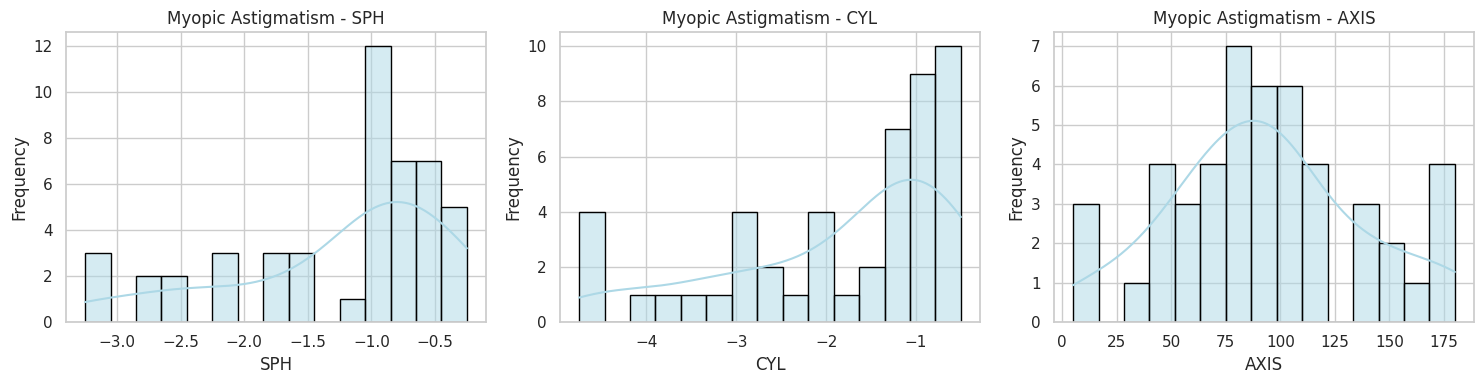

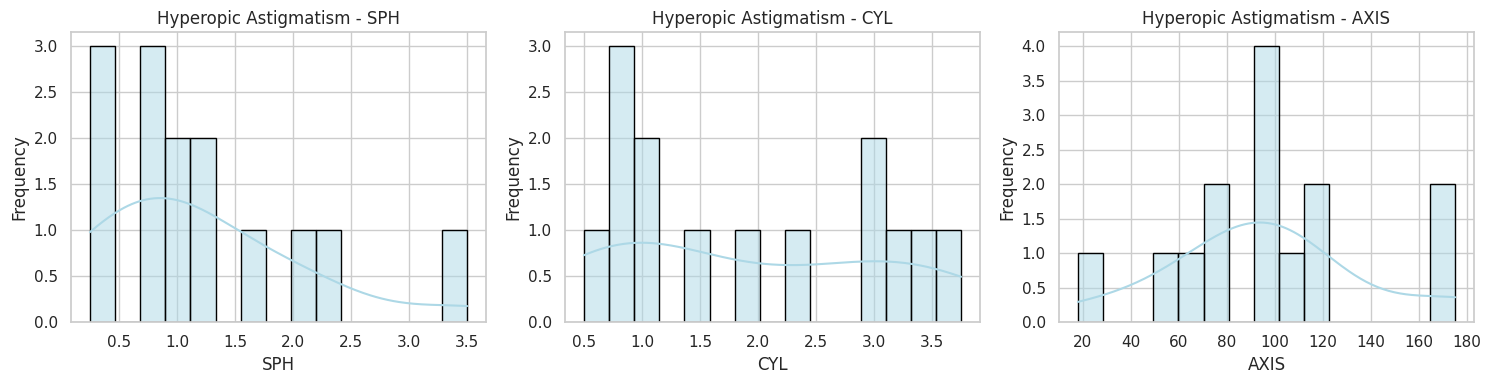

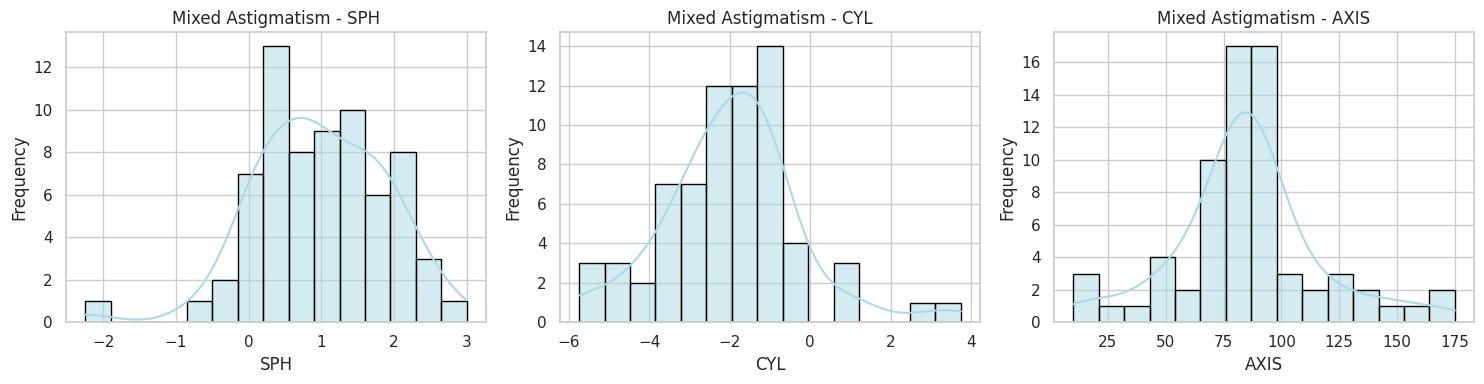

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hist_with_kde(group_df, title_prefix):
    plt.figure(figsize=(15, 4))

    for i, col in enumerate(['SPH', 'CYL', 'AXIS']):
        plt.subplot(1, 3, i+1)
        sns.histplot(group_df[col].dropna(), kde=True, bins=15, color='lightblue', edgecolor='black')
        plt.title(f"{title_prefix} - {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Plot with bell curves for each group
plot_hist_with_kde(myopic_df, "Myopic Astigmatism")
plot_hist_with_kde(hyperopic_df, "Hyperopic Astigmatism")
plot_hist_with_kde(mixed_df, "Mixed Astigmatism")


/tmp/ipython-input-3783661550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='SPH', data=day1AR, palette='pastel')


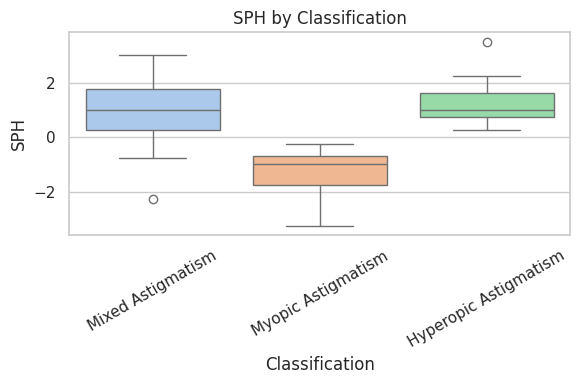

/tmp/ipython-input-3783661550.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='CYL', data=day1AR, palette='pastel')


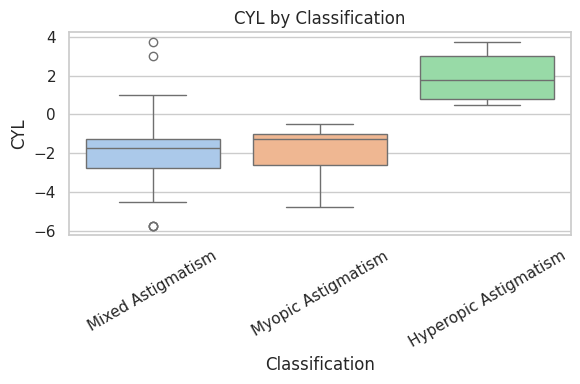

/tmp/ipython-input-3783661550.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='AXIS', data=day1AR, palette='pastel')


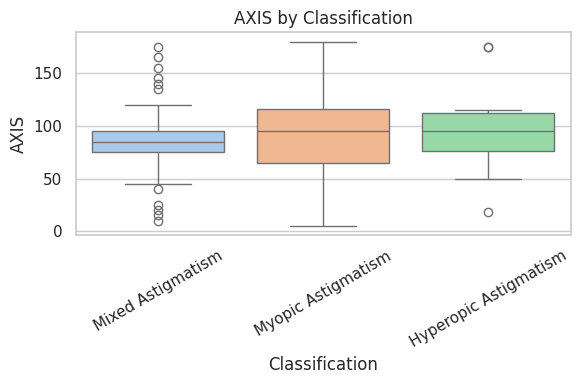

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Boxplot for SPH
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='SPH', data=day1AR, palette='pastel')
plt.title('SPH by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for CYL
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='CYL', data=day1AR, palette='pastel')
plt.title('CYL by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for AXIS
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='AXIS', data=day1AR, palette='pastel')
plt.title('AXIS by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [57]:
day1AR['preopcyl'] = day1AR['KV']-day1AR['KH']
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism,1.25
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism,0.50
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism,1.50
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism,1.00
...,...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,Myopic Astigmatism,0.75
167,47.00,48.25,165,1.25,-1.75,15.0,Mixed Astigmatism,1.25
168,42.00,42.50,110,-0.75,-1.25,95.0,Myopic Astigmatism,0.50
169,45.00,46.25,165,-2.75,-3.00,75.0,Myopic Astigmatism,1.25


In [58]:
myopic_df['preopcyl'] = myopic_df['KV']-myopic_df['KH']
myopic_df

/tmp/ipython-input-1664374083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myopic_df['preopcyl'] = myopic_df['KV']-myopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism,0.50
7,43.00,44.50,90,-1,-0.50,100.0,Myopic Astigmatism,1.50
12,43.00,43.75,65,-1,-1.00,95.0,Myopic Astigmatism,0.75
17,44.75,45.25,80,-1.75,-1.25,15.0,Myopic Astigmatism,0.50
32,41.00,41.75,145,-0.5,-1.00,100.0,Myopic Astigmatism,0.75
37,43.25,44.00,125,-1.75,-3.75,80.0,Myopic Astigmatism,0.75
41,40.25,41.25,75,-1,-0.75,70.0,Myopic Astigmatism,1.00
42,44.00,44.25,140,-1.5,-1.00,50.0,Myopic Astigmatism,0.25
50,44.00,44.50,155,-0.75,-0.50,30.0,Myopic Astigmatism,0.50
52,45.00,45.25,175,-0.75,-1.25,75.0,Myopic Astigmatism,0.25


In [59]:
hyperopic_df['preopcyl'] = hyperopic_df['KV']-hyperopic_df['KH']
hyperopic_df


/tmp/ipython-input-970133251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyperopic_df['preopcyl'] = hyperopic_df['KV']-hyperopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism,1.50
9,47.50,48.00,5,0.25,3.50,18.0,Hyperopic Astigmatism,0.50
19,43.75,45.00,85,2,3.00,105.0,Hyperopic Astigmatism,1.25
67,46.00,48.25,170,1,0.75,95.0,Hyperopic Astigmatism,2.25
76,44.50,44.75,55,1,0.50,95.0,Hyperopic Astigmatism,0.25
95,46.75,47.00,75,2.25,3.00,175.0,Hyperopic Astigmatism,0.25
110,44.00,45.50,90,1.75,2.25,100.0,Hyperopic Astigmatism,1.50
112,41.75,42.25,85,1.25,1.00,65.0,Hyperopic Astigmatism,0.50
113,45.25,46.00,90,1.25,0.75,115.0,Hyperopic Astigmatism,0.75
135,43.75,43.75,180,0.75,0.75,115.0,Hyperopic Astigmatism,0.00


In [60]:
mixed_df['preopcyl'] = mixed_df['KV']-mixed_df['KH']
mixed_df


/tmp/ipython-input-3961326065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['preopcyl'] = mixed_df['KV']-mixed_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism,1.25
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism,1.00
6,43.50,44.00,20,-0.5,3.75,75.0,Mixed Astigmatism,0.50
8,44.75,45.25,85,1.5,-3.25,45.0,Mixed Astigmatism,0.50
...,...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,Mixed Astigmatism,0.25
155,44.25,45.75,80,1.25,-1.00,80.0,Mixed Astigmatism,1.50
159,41.75,43.50,160,-2.25,3.00,50.0,Mixed Astigmatism,1.75
163,45.25,45.25,180,1.75,-4.25,95.0,Mixed Astigmatism,0.00


In [102]:
myopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl,postopcyl,preoptheta,postoptheta,prex,prey,postx,posty,Xsia,Ysia,SIAmagnitude,SIA_magnitude,SIA_axis
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism,0.50,-1.00,4.188790,5.585054,0.407090,0.290306,0.975629,-0.219425,0.568539,-0.509731,1.363278,0.763585,159.060887
7,43.00,44.50,90,-1,-0.50,100.0,Myopic Astigmatism,1.50,-0.50,3.141593,3.490659,-0.672110,1.340995,-0.431159,0.253183,0.240951,-1.087812,1.682942,1.114178,141.244699
12,43.00,43.75,65,-1,-1.00,95.0,Myopic Astigmatism,0.75,-1.00,2.268928,3.316126,-0.421840,0.620122,-0.730174,-0.683262,-0.308333,-1.303383,1.535087,1.339357,128.345287
17,44.75,45.25,80,-1.75,-1.25,15.0,Myopic Astigmatism,0.50,-1.25,2.792527,0.523599,-0.055194,-0.496944,0.949610,-0.812860,1.004804,-0.315915,1.535087,1.053296,171.273290
32,41.00,41.75,145,-0.5,-1.00,100.0,Myopic Astigmatism,0.75,-1.00,5.061455,3.490659,0.662898,0.350809,-0.862319,0.506366,-1.525216,0.155557,1.535087,1.533128,87.088271
37,43.25,44.00,125,-1.75,-3.75,80.0,Myopic Astigmatism,0.75,-3.75,4.363323,2.792527,0.590786,-0.462030,0.413952,3.727082,-0.176834,4.189113,1.556146,4.192843,46.208587
41,40.25,41.25,75,-1,-0.75,70.0,Myopic Astigmatism,1.00,-0.75,2.617994,2.443461,0.921751,-0.387782,-0.474989,-0.580418,-1.396741,-0.192636,1.535087,1.409962,93.926304
42,44.00,44.25,140,-1.5,-1.00,50.0,Myopic Astigmatism,0.25,-1.00,4.886922,1.745329,-0.049453,0.245060,-0.964966,0.262375,-0.915513,0.017315,1.170195,0.915676,89.458252
50,44.00,44.50,155,-0.75,-0.50,30.0,Myopic Astigmatism,0.50,-0.50,5.410521,1.047198,-0.243581,-0.436656,-0.077126,0.494016,0.166455,0.930672,0.958851,0.945440,39.929802
52,45.00,45.25,175,-0.75,-1.25,75.0,Myopic Astigmatism,0.25,-1.25,6.108652,2.617994,0.149621,-0.200284,-1.152189,0.484727,-1.301810,0.685011,1.363278,1.471037,76.123358


In [101]:
myopic_df['postopcyl'] = myopic_df['CYL']
myopic_df['preoptheta'] = np.deg2rad(myopic_df['AX']*2)
myopic_df['postoptheta'] = np.deg2rad(myopic_df['AXIS']*2)
myopic_df['prex'] = myopic_df['preopcyl']*np.cos(myopic_df['AX'])
myopic_df['prey'] = myopic_df['preopcyl']*np.sin(myopic_df['AX'])
myopic_df['postx'] = myopic_df['postopcyl']*np.cos(myopic_df['AXIS'])
myopic_df['posty'] = myopic_df['postopcyl']*np.sin(myopic_df['AXIS'])
myopic_df['Xsia'] = myopic_df['postx'] - myopic_df['prex']
myopic_df['Ysia'] = myopic_df['posty'] - myopic_df['prey']
myopic_df['SIA_magnitude'] = np.sqrt(myopic_df['Xsia']**2 + myopic_df['Ysia']**2)
myopic_df['SIA_axis'] = np.rad2deg(np.arctan2(myopic_df['Ysia'], myopic_df['Xsia']))/2 % 180.0



/tmp/ipython-input-2699590827.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myopic_df['postopcyl'] = myopic_df['CYL']
/tmp/ipython-input-2699590827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myopic_df['preoptheta'] = np.deg2rad(myopic_df['AX']*2)
/tmp/ipython-input-2699590827.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [106]:
import numpy as np

def to_cartesian(cyl, axis_deg):
    # Convert cylinder vector to X, Y components
    angle_rad = np.deg2rad(2 * axis_deg)  # double angle for astigmatism
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

def from_cartesian(x, y):
    # Convert X, Y to cylinder and axis
    cyl = np.hypot(x, y)  # magnitude
    axis = np.rad2deg(np.arctan2(y, x)) / 2  # halve angle back
    if axis < 0:
        axis += 180  # normalize between 0-180
    return cyl, axis

def calculate_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    # Convert pre- and post-op to Cartesian
    x_pre, y_pre = to_cartesian(pre_cyl, pre_axis)
    x_post, y_post = to_cartesian(post_cyl, post_axis)

    # SIA vector = post - pre
    x_sia = x_post - x_pre
    y_sia = y_post - y_pre

    # SIA magnitude and axis
    sia_mag, sia_axis = from_cartesian(x_sia, y_sia)

    print(f"Pre-op vector (X, Y): ({x_pre:.2f}, {y_pre:.2f})")
    print(f"Post-op vector (X, Y): ({x_post:.2f}, {y_post:.2f})")
    print(f"SIA vector (X, Y): ({x_sia:.2f}, {y_sia:.2f})")
    print(f"SIA Magnitude: {sia_mag:.2f} D")
    print(f"SIA Axis: {sia_axis:.2f}°")

# Example input (in diopters and degrees)
pre_cyl = 0.50
pre_axis = 120
post_cyl = -1.00
post_axis = 180

calculate_sia(pre_cyl, pre_axis, post_cyl, post_axis)


Pre-op vector (X, Y): (-0.25, -0.43)
Post-op vector (X, Y): (-1.00, 0.00)
SIA vector (X, Y): (-0.75, 0.43)
SIA Magnitude: 0.87 D
SIA Axis: 75.00°
